# Brecha Digital Territorial en Cusco

Cruce de luces nocturnas (NASA VNL 2025) con cobertura móvil OSIPTEL 2019 para identificar zonas con brecha digital activa en la región Cusco.

Pipeline: carga raster → reproyección a EPSG:4326 → normalización p2-p98 → índices (IBD, EDT) → mapas temáticos → clasificación 2x2 → stats.

## Step 0 — Setup

Imports y versiones de las librerías para reproducibilidad.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.transform import array_bounds
import scipy
from scipy import ndimage, stats

print('rasterio  ', rasterio.__version__)
print('numpy     ', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('scipy     ', scipy.__version__)
print('seaborn   ', sns.__version__)
print('pandas    ', pd.__version__)

sns.set_context('notebook')

# Rutas relativas. Soporta ejecución desde notebooks/ y desde la raiz del repo.
for candidate in [Path('../data'), Path('data')]:
    if candidate.exists():
        DATA = candidate.resolve()
        break
OUT = (DATA.parent / 'output')
OUT.mkdir(exist_ok=True)
print('DATA dir  ', DATA)
print('OUTPUT dir', OUT)

rasterio   1.5.0
numpy      2.4.4
matplotlib 3.10.8
scipy      1.17.1
seaborn    0.13.2
pandas     3.0.2
DATA dir   C:\Users\manue\OneDrive\Documentos\GitHub\raster-digital-divide\data
OUTPUT dir C:\Users\manue\OneDrive\Documentos\GitHub\raster-digital-divide\output


## Step 1 — Loading e inspección

Para cada raster imprimo CRS, shape, bandas, NoData, dtype, bbox, resolución y rango de valores.

In [2]:
def km_per_pixel(transform, height, width, crs):
    """Aprox de tamaño de pixel en km, dependiendo del CRS."""
    dx, dy = abs(transform.a), abs(transform.e)
    if crs and crs.is_geographic:
        bounds = array_bounds(height, width, transform)
        lat_mid = 0.5 * (bounds[1] + bounds[3])
        kx = dx * 111.32 * np.cos(np.deg2rad(lat_mid))
        ky = dy * 110.57
        return dx, dy, kx, ky, 'deg'
    return dx, dy, dx / 1000.0, dy / 1000.0, 'm'


def inspect_raster(path, label):
    with rasterio.open(path) as ds:
        arr = ds.read(1, masked=True)
        dx, dy, kx, ky, unit = km_per_pixel(ds.transform, ds.height, ds.width, ds.crs)
        valid = int(arr.count())
        total = int(arr.size)
        amin = float(arr.min()) if valid else float('nan')
        amax = float(arr.max()) if valid else float('nan')
        print(f'=== {label} ===')
        print(f'  path     : {path.name}')
        print(f'  CRS      : {ds.crs}')
        print(f'  shape    : {ds.height} x {ds.width} (alto x ancho)')
        print(f'  bandas   : {ds.count}')
        print(f'  NoData   : {ds.nodata}')
        print(f'  dtype    : {ds.dtypes[0]}')
        print(f'  bbox     : {ds.bounds}')
        print(f'  pixel    : {dx:.6f} x {dy:.6f} {unit}  (~{kx*1000:.0f} x {ky*1000:.0f} m)')
        print(f'  validos  : {valid:,} / {total:,} pixeles')
        print(f'  rango    : [{amin:.6g}, {amax:.6g}]')
        print()
        return arr


VNL_PATH = DATA / 'VNL_cusco_2025.tif'
KERN_PATH = DATA / 'kernel_cobmovil2019_50m.tif'

vnl_arr = inspect_raster(VNL_PATH, 'VNL_cusco_2025 (NASA Black Marble)')
kern_arr = inspect_raster(KERN_PATH, 'kernel_cobmovil2019_50m (OSIPTEL)')

=== VNL_cusco_2025 (NASA Black Marble) ===
  path     : VNL_cusco_2025.tif
  CRS      : EPSG:4326
  shape    : 1081 x 961 (alto x ancho)
  bandas   : 1
  NoData   : None
  dtype    : float32
  bbox     : BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  pixel    : 0.004167 x 0.004167 deg  (~451 x 461 m)
  validos  : 1,038,841 / 1,038,841 pixeles
  rango    : [-1.5, 1254.61]



=== kernel_cobmovil2019_50m (OSIPTEL) ===
  path     : kernel_cobmovil2019_50m.tif
  CRS      : EPSG:32719
  shape    : 6116 x 7754 (alto x ancho)
  bandas   : 1
  NoData   : -3.4028234663852886e+38
  dtype    : float32
  bbox     : BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  pixel    : 50.000000 x 50.000000 m  (~50 x 50 m)
  validos  : 47,423,464 / 47,423,464 pixeles
  rango    : [0, 3.13465e-06]



## Step 2 — Reproyección y alineación

El kernel OSIPTEL viene en EPSG:32719 (UTM 19S, metros). Lo reproyecto a EPSG:4326 con resampling bilineal y lo paso a la grilla exacta del VNL (mismo transform, mismo shape).

In [3]:
with rasterio.open(VNL_PATH) as vnl_ds:
    vnl_transform = vnl_ds.transform
    vnl_crs = vnl_ds.crs
    vnl_shape = (vnl_ds.height, vnl_ds.width)
    vnl_bounds = vnl_ds.bounds
    vnl_data = vnl_ds.read(1).astype('float32')
    vnl_nodata = vnl_ds.nodata
    vnl_profile = vnl_ds.profile

with rasterio.open(KERN_PATH) as kern_ds:
    kern_src = kern_ds.read(1).astype('float32')
    kern_transform_src = kern_ds.transform
    kern_crs_src = kern_ds.crs
    kern_nodata_src = kern_ds.nodata

# Reproyecto el kernel directo a la grilla del VNL
conn = np.full(vnl_shape, np.nan, dtype='float32')
reproject(
    source=kern_src,
    destination=conn,
    src_transform=kern_transform_src,
    src_crs=kern_crs_src,
    dst_transform=vnl_transform,
    dst_crs=vnl_crs,
    resampling=Resampling.bilinear,
    src_nodata=kern_nodata_src,
    dst_nodata=np.nan,
)

assert conn.shape == vnl_data.shape, 'shapes no coinciden'
print(f'VNL shape           : {vnl_data.shape}')
print(f'Conn reproyectada   : {conn.shape}')
print(f'mismo grid?         : {conn.shape == vnl_data.shape}')
print(f'CRS final           : {vnl_crs}')
print(f'extent (W,S,E,N)    : {vnl_bounds}')
valid_conn = int(np.sum(~np.isnan(conn)))
print(f'pixeles validos conn: {valid_conn:,} / {conn.size:,}')

VNL shape           : (1081, 961)
Conn reproyectada   : (1081, 961)
mismo grid?         : True
CRS final           : EPSG:4326
extent (W,S,E,N)    : BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
pixeles validos conn: 566,647 / 1,038,841


## Step 3 — Normalización robusta (p2 a p98)

Negativos y NaN/NoData los reemplazo por 0 antes del clip. Uso percentil [2, 98] para ser robusto contra outliers (un pico de VNL muy alto en el centro de la ciudad no debe saturar todo el rango). El resultado queda en [0, 1] en ambas capas.

In [4]:
def normalize_p298(arr):
    a = np.where(np.isnan(arr) | (arr < 0), 0.0, arr).astype('float32')
    p2, p98 = np.percentile(a, [2, 98])
    out = np.clip((a - p2) / (p98 - p2 + 1e-12), 0.0, 1.0).astype('float32')
    return out, float(p2), float(p98)


vnl_norm, vnl_p2, vnl_p98 = normalize_p298(vnl_data)
conn_norm, conn_p2, conn_p98 = normalize_p298(conn)

for label, x, p2, p98 in [
    ('VNL_norm', vnl_norm, vnl_p2, vnl_p98),
    ('Conn_norm', conn_norm, conn_p2, conn_p98),
]:
    print(f'{label}:  p2={p2:.6g}, p98={p98:.6g}')
    print(f'   min={x.min():.4f}  max={x.max():.4f}  mean={x.mean():.4f}  std={x.std():.4f}')
    print()

VNL_norm:  p2=0, p98=0.633383
   min=0.0000  max=1.0000  mean=0.0391  std=0.1767

Conn_norm:  p2=0, p98=3.26232e-07
   min=0.0000  max=1.0000  mean=0.0389  std=0.1688



## Step 4 — Mapa 1: Luces Nocturnas (VNL)

VNL raw (radiancia en nW·cm⁻²·sr⁻¹) y VNL normalizado [0, 1] lado a lado. Colormap inferno con extent geográfico. Las zonas brillantes corresponden a centros urbanos y carreteras iluminadas; el resto es ruralidad casi sin emisión.

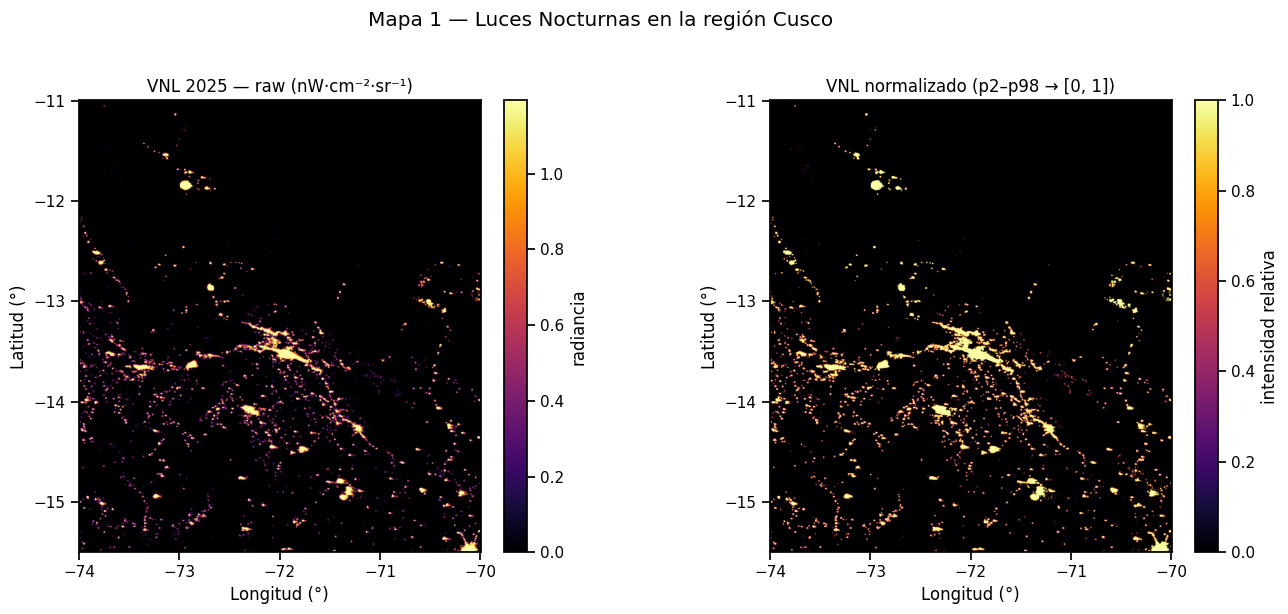

Observación: las zonas brillantes en el VNL coinciden con la ciudad de Cusco y los
corredores poblados del valle del Vilcanota. La normalización p2-p98 comprime la
cola larga de la radiancia y revela núcleos urbanos secundarios que en la imagen
cruda quedaban opacados por el pico del centro histórico.


In [5]:
extent_geo = [vnl_bounds.left, vnl_bounds.right, vnl_bounds.bottom, vnl_bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vnl_raw_plot = np.where(np.isnan(vnl_data) | (vnl_data < 0), 0, vnl_data)
im0 = axes[0].imshow(vnl_raw_plot, cmap='inferno', extent=extent_geo, origin='upper',
                     vmin=0, vmax=np.percentile(vnl_raw_plot, 99))
axes[0].set_title('VNL 2025 — raw (nW·cm⁻²·sr⁻¹)')
axes[0].set_xlabel('Longitud (°)')
axes[0].set_ylabel('Latitud (°)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='radiancia')

im1 = axes[1].imshow(vnl_norm, cmap='inferno', extent=extent_geo, origin='upper', vmin=0, vmax=1)
axes[1].set_title('VNL normalizado (p2–p98 → [0, 1])')
axes[1].set_xlabel('Longitud (°)')
axes[1].set_ylabel('Latitud (°)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='intensidad relativa')

fig.suptitle('Mapa 1 — Luces Nocturnas en la región Cusco', y=1.02)
plt.tight_layout()
plt.show()

print('Observación: las zonas brillantes en el VNL coinciden con la ciudad de Cusco y los')
print('corredores poblados del valle del Vilcanota. La normalización p2-p98 comprime la')
print('cola larga de la radiancia y revela núcleos urbanos secundarios que en la imagen')
print('cruda quedaban opacados por el pico del centro histórico.')

## Step 5 — Mapa 2: Índices de Brecha (IBD) y Exclusión (EDT)

- **IBD (Índice Brecha Digital) = VNL_norm − Conn_norm**, rango [−1, 1]. Cmap `RdYlGn_r`: rojos = más luz que conectividad (brecha digital activa), verdes = bien conectado.
- **EDT (Exclusión Digital Total) = (1 − VNL_norm) × (1 − Conn_norm)**, rango [0, 1]. Cmap `Purples`: alto = sin luces ni conectividad.

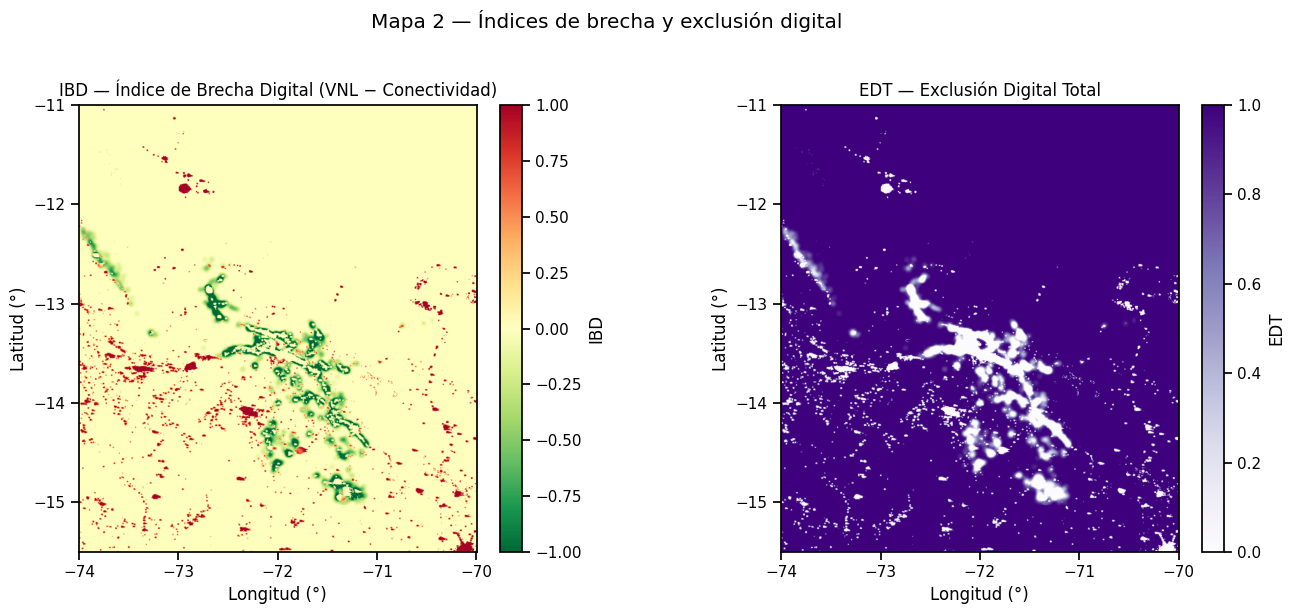

IBD:  min=-1.000  max=1.000  mean=0.000
EDT:  min=0.000  max=1.000  mean=0.934

Interpretación IBD: zonas rojas tienen luz urbana pero baja cobertura móvil —
la población existe pero no tiene servicio. Las zonas verdes están bien servidas.
Interpretación EDT: los morados profundos son áreas rurales sin actividad nocturna
detectable ni cobertura — exclusión digital máxima.


In [6]:
ibd = (vnl_norm - conn_norm).astype('float32')
edt = ((1.0 - vnl_norm) * (1.0 - conn_norm)).astype('float32')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(ibd, cmap='RdYlGn_r', extent=extent_geo, origin='upper', vmin=-1, vmax=1)
axes[0].set_title('IBD — Índice de Brecha Digital (VNL − Conectividad)')
axes[0].set_xlabel('Longitud (°)')
axes[0].set_ylabel('Latitud (°)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='IBD')

im1 = axes[1].imshow(edt, cmap='Purples', extent=extent_geo, origin='upper', vmin=0, vmax=1)
axes[1].set_title('EDT — Exclusión Digital Total')
axes[1].set_xlabel('Longitud (°)')
axes[1].set_ylabel('Latitud (°)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='EDT')

fig.suptitle('Mapa 2 — Índices de brecha y exclusión digital', y=1.02)
plt.tight_layout()
plt.show()

print(f'IBD:  min={ibd.min():.3f}  max={ibd.max():.3f}  mean={ibd.mean():.3f}')
print(f'EDT:  min={edt.min():.3f}  max={edt.max():.3f}  mean={edt.mean():.3f}')
print()
print('Interpretación IBD: zonas rojas tienen luz urbana pero baja cobertura móvil —')
print('la población existe pero no tiene servicio. Las zonas verdes están bien servidas.')
print('Interpretación EDT: los morados profundos son áreas rurales sin actividad nocturna')
print('detectable ni cobertura — exclusión digital máxima.')

## Step 6 — Mapa 3: Prioridad de Intervención (P1/P2/P3)

Clasifico cada pixel en función de la luz nocturna (proxy de población) y la cobertura móvil:

| Nivel | Condición | Lectura |
|-------|-----------|---------|
| **P3 Critical** | VNL ≥ 0.30 y Conn < 0.10 | Alta densidad, sin internet |
| **P2 High** | VNL ≥ 0.15 y Conn < 0.15 | Periferia urbana, cobertura incompleta |
| **P1 Medium** | VNL ≥ 0.10 y Conn < 0.25 | Peri-urbano, cobertura parcial |

Asigno el nivel más alto que aplique a cada pixel.

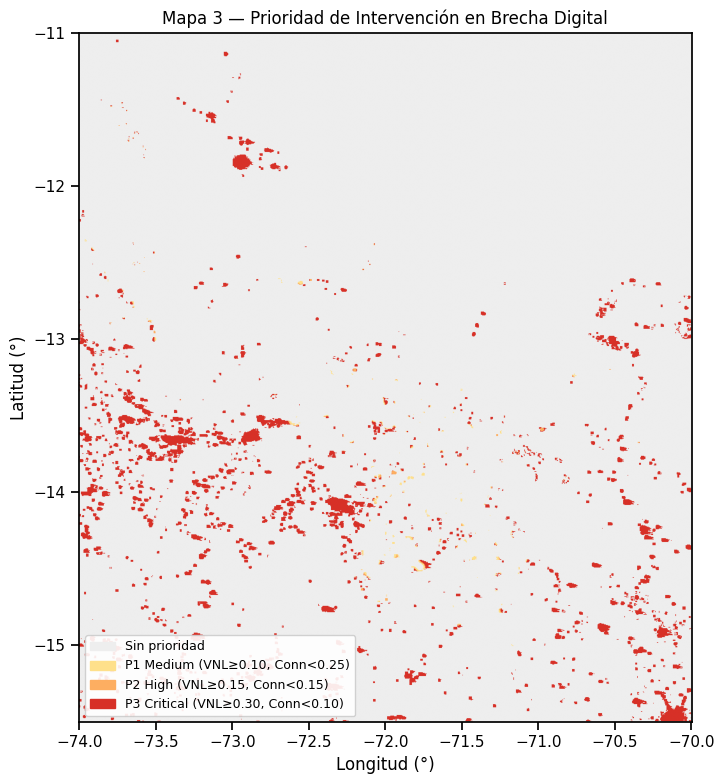

Conteo por nivel de prioridad:
  P1 Medium     :      876 pixeles  ( 0.08% del área)
  P2 High       :      653 pixeles  ( 0.06% del área)
  P3 Critical   :   34,523 pixeles  ( 3.32% del área)
  sin prioridad : 1,002,789 pixeles  (96.53%)


In [7]:
import matplotlib.patches as mpatches

priority = np.zeros(vnl_norm.shape, dtype='int8')
mask_p1 = (vnl_norm >= 0.10) & (conn_norm < 0.25)
mask_p2 = (vnl_norm >= 0.15) & (conn_norm < 0.15)
mask_p3 = (vnl_norm >= 0.30) & (conn_norm < 0.10)
priority[mask_p1] = 1
priority[mask_p2] = 2  # P2 sobreescribe a P1 cuando ambos aplican
priority[mask_p3] = 3  # P3 sobreescribe a P2

prio_colors = ['#eeeeee', '#fee08b', '#fdae61', '#d73027']
prio_labels = [
    'Sin prioridad',
    'P1 Medium (VNL≥0.10, Conn<0.25)',
    'P2 High (VNL≥0.15, Conn<0.15)',
    'P3 Critical (VNL≥0.30, Conn<0.10)',
]
prio_cmap = mcolors.ListedColormap(prio_colors)
prio_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(priority, cmap=prio_cmap, norm=prio_norm, extent=extent_geo, origin='upper')
ax.set_title('Mapa 3 — Prioridad de Intervención en Brecha Digital')
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
handles = [mpatches.Patch(color=c, label=l) for l, c in zip(prio_labels, prio_colors)]
ax.legend(handles=handles, loc='lower left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

total = priority.size
print('Conteo por nivel de prioridad:')
for level, name in [(1, 'P1 Medium'), (2, 'P2 High'), (3, 'P3 Critical')]:
    c = int((priority == level).sum())
    pct = 100 * c / total
    print(f'  {name:14s}: {c:>8,} pixeles  ({pct:5.2f}% del área)')
sin_p = int((priority == 0).sum())
print(f'  {"sin prioridad":14s}: {sin_p:>8,} pixeles  ({100*sin_p/total:5.2f}%)')

## Step 7 — Mapa 4: Riesgo de Exclusión Social

`Risk = EDT × (1 − VNL_norm)`, renormalizado a [0, 1]. Aplico un filtro gaussiano con σ=5 para revelar los clusters regionales en lugar de pixeles aislados, y reporto los percentiles 75 y 90 para tener thresholds reproducibles.

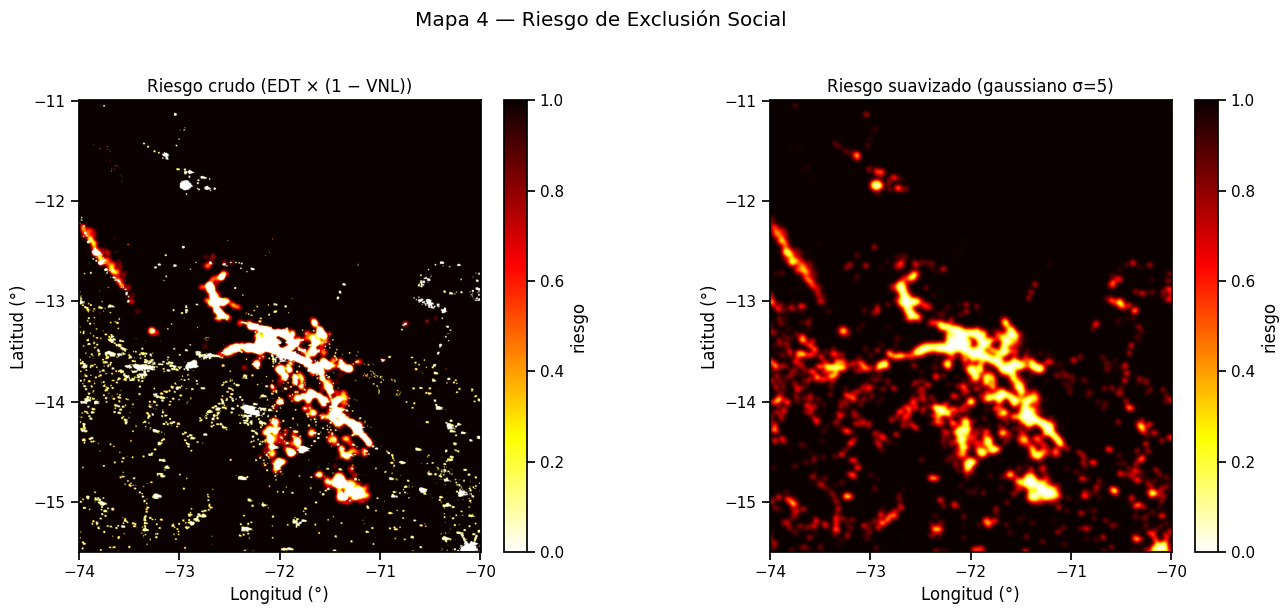

Riesgo crudo     : p75=1.000  p90=1.000
Riesgo suavizado : p75=1.000  p90=1.000


In [8]:
risk_raw = (edt * (1.0 - vnl_norm)).astype('float32')
risk_raw_norm = risk_raw / (risk_raw.max() + 1e-12)
risk_smoothed = ndimage.gaussian_filter(risk_raw_norm, sigma=5.0).astype('float32')
risk_smoothed = risk_smoothed / (risk_smoothed.max() + 1e-12)

p75_raw, p90_raw = np.percentile(risk_raw_norm, [75, 90])
p75_sm, p90_sm = np.percentile(risk_smoothed, [75, 90])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(risk_raw_norm, cmap='hot_r', extent=extent_geo, origin='upper', vmin=0, vmax=1)
axes[0].set_title('Riesgo crudo (EDT × (1 − VNL))')
axes[0].set_xlabel('Longitud (°)')
axes[0].set_ylabel('Latitud (°)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='riesgo')

im1 = axes[1].imshow(risk_smoothed, cmap='hot_r', extent=extent_geo, origin='upper', vmin=0, vmax=1)
axes[1].set_title('Riesgo suavizado (gaussiano σ=5)')
axes[1].set_xlabel('Longitud (°)')
axes[1].set_ylabel('Latitud (°)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='riesgo')

fig.suptitle('Mapa 4 — Riesgo de Exclusión Social', y=1.02)
plt.tight_layout()
plt.show()

print(f'Riesgo crudo     : p75={p75_raw:.3f}  p90={p90_raw:.3f}')
print(f'Riesgo suavizado : p75={p75_sm:.3f}  p90={p90_sm:.3f}')

## Step 8 — Clasificación Territorial 2×2

Aplico thresholds `VNL ≥ 0.15` y `Conn ≥ 0.15` para cuatro clases:

| Clase | Nombre | VNL | Conectividad | Color |
|-------|--------|-----|--------------|-------|
| 1 | Urban Connected | alta | alta | verde |
| 2 | Urban Divide | alta | baja | rojo |
| 3 | Rural Connected | baja | alta | azul |
| 4 | Critical Divide | baja | baja | morado |

DataFrame con conteos, porcentajes y área aproximada en km² (usando km/grado a la latitud media de Cusco). Exporto el raster como GeoTIFF.

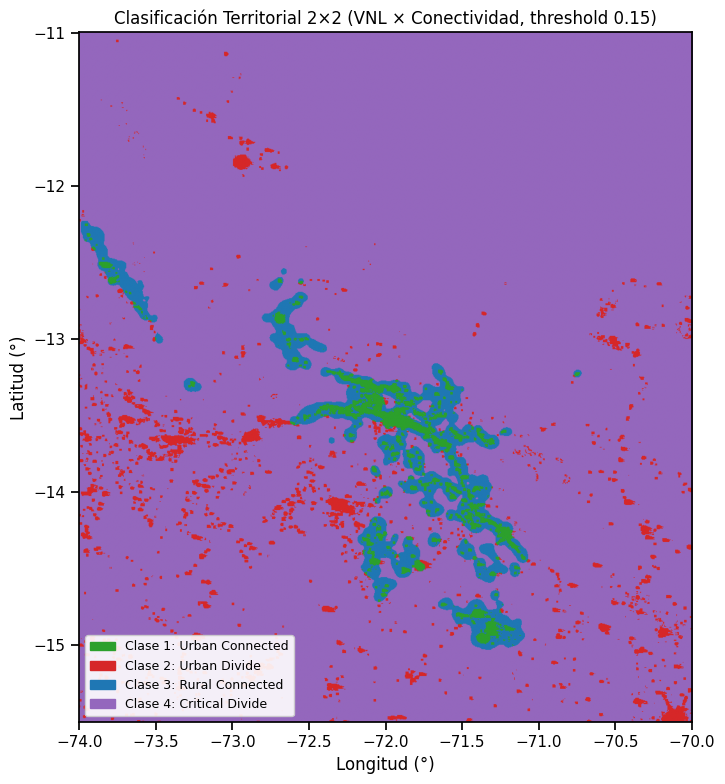

área aprox por pixel: 0.2080 km²  (lat media=-13.25°)

 clase          nombre  pixels  pct_area  area_km2
     1 Urban Connected   17522      1.69   3644.63
     2    Urban Divide   35176      3.39   7316.72
     3 Rural Connected   42430      4.08   8825.58
     4 Critical Divide  943713     90.84 196295.37

Guardado: C:\Users\manue\OneDrive\Documentos\GitHub\raster-digital-divide\output\clasificacion_brecha.tif


In [9]:
clasif = np.zeros(vnl_norm.shape, dtype='uint8')
mask_urb = vnl_norm >= 0.15
mask_con = conn_norm >= 0.15
clasif[mask_urb & mask_con] = 1   # Urban Connected
clasif[mask_urb & ~mask_con] = 2  # Urban Divide
clasif[~mask_urb & mask_con] = 3  # Rural Connected
clasif[~mask_urb & ~mask_con] = 4  # Critical Divide

class_names = ['—', 'Urban Connected', 'Urban Divide', 'Rural Connected', 'Critical Divide']
class_colors = ['#ffffff', '#2ca02c', '#d62728', '#1f77b4', '#9467bd']
cl_cmap = mcolors.ListedColormap(class_colors)
cl_bnorm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(clasif, cmap=cl_cmap, norm=cl_bnorm, extent=extent_geo, origin='upper')
ax.set_title('Clasificación Territorial 2×2 (VNL × Conectividad, threshold 0.15)')
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
handles = [mpatches.Patch(color=class_colors[i], label=f'Clase {i}: {class_names[i]}') for i in range(1, 5)]
ax.legend(handles=handles, loc='lower left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

# Área aproximada por pixel a la latitud media de Cusco
dx_deg = abs(vnl_transform.a)
dy_deg = abs(vnl_transform.e)
lat_mid = 0.5 * (vnl_bounds.bottom + vnl_bounds.top)
km_per_deg_x = 111.32 * np.cos(np.deg2rad(lat_mid))
km_per_deg_y = 110.57
area_pix_km2 = dx_deg * km_per_deg_x * dy_deg * km_per_deg_y
print(f'área aprox por pixel: {area_pix_km2:.4f} km²  (lat media={lat_mid:.2f}°)')

rows = []
total_pix = clasif.size
for c in range(1, 5):
    count = int((clasif == c).sum())
    pct = 100 * count / total_pix
    area = count * area_pix_km2
    rows.append({
        'clase': c,
        'nombre': class_names[c],
        'pixels': count,
        'pct_area': round(pct, 2),
        'area_km2': round(area, 2),
    })
clasif_df = pd.DataFrame(rows)
print()
print(clasif_df.to_string(index=False))

# Export GeoTIFF de la clasificación
prof = vnl_profile.copy()
prof.update(dtype='uint8', count=1, nodata=0, compress='lzw')
with rasterio.open(OUT / 'clasificacion_brecha.tif', 'w', **prof) as dst:
    dst.write(clasif.astype('uint8'), 1)
print(f'\nGuardado: {OUT / "clasificacion_brecha.tif"}')

## Step 9 — Estadística

- Descriptivas (mean, std, min, max) por clase para VNL_norm, Conn_norm e IBD.
- Pearson VNL vs Conectividad con subsample cada 40 pixeles.
- KDE plots de VNL y Conn, una curva por clase, en una sola figura.
- Welch t-test entre Clase 1 (Urban Connected) y Clase 4 (Critical Divide) sobre VNL: t, p y Cohen's d.

=== Stats descriptivas por clase ===


                    vnl                            conn                  \
                   mean     std     min     max    mean     std     min   
Urban Connected  0.8318  0.2067  0.3013  1.0000  0.8458  0.2570  0.1501   
Urban Divide     0.7391  0.2335  0.1579  1.0000  0.0034  0.0178  0.0000   
Rural Connected  0.0000  0.0000  0.0000  0.0000  0.5604  0.3068  0.1500   
Critical Divide  0.0000  0.0004  0.0000  0.1457  0.0018  0.0124  0.0000   

                            ibd                          
                    max    mean     std     min     max  
Urban Connected  1.0000 -0.0140  0.2886 -0.6979  0.8499  
Urban Divide     0.1499  0.7357  0.2347  0.1579  1.0000  
Rural Connected  1.0000 -0.5604  0.3068 -1.0000 -0.1500  
Critical Divide  0.1500 -0.0018  0.0124 -0.1500  0.1457  

Pearson(VNL_norm, Conn_norm) sub 1:40 (n=25,972): r = 0.3472, p = 0


C:\Users\manue\AppData\Local\Temp\ipykernel_55244\4192924758.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(s['vnl'], ax=axes[0], label=f'C{ci} {class_names[ci]}',


C:\Users\manue\AppData\Local\Temp\ipykernel_55244\4192924758.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(s['vnl'], ax=axes[0], label=f'C{ci} {class_names[ci]}',


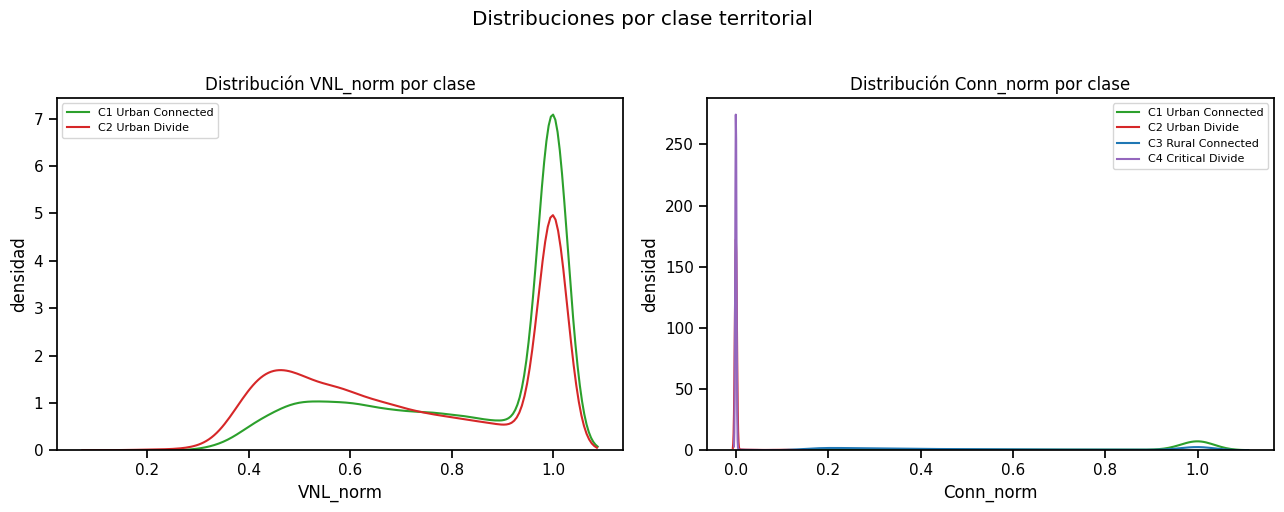


=== Welch t-test VNL: Clase 1 (Urban Connected) vs Clase 4 (Critical Divide) ===
  n1   = 17,522    n2   = 943,713
  mean1= 0.8318  mean2= 0.0000
  t    = 532.6776
  p    < 2.2e-308 (underflow)
  Cohen's d = 29.8037


In [10]:
flat = pd.DataFrame({
    'clase': clasif.flatten(),
    'vnl': vnl_norm.flatten(),
    'conn': conn_norm.flatten(),
    'ibd': ibd.flatten(),
})
flat = flat[flat['clase'] > 0]

print('=== Stats descriptivas por clase ===')
descr = flat.groupby('clase')[['vnl', 'conn', 'ibd']].agg(['mean', 'std', 'min', 'max']).round(4)
descr.index = [class_names[i] for i in descr.index]
print(descr)

# Pearson VNL vs Conn con subsample cada 40 pixeles
v_sub = vnl_norm.flatten()[::40]
c_sub = conn_norm.flatten()[::40]
r, pval = stats.pearsonr(v_sub, c_sub)
print(f'\nPearson(VNL_norm, Conn_norm) sub 1:40 (n={len(v_sub):,}): r = {r:.4f}, p = {pval:.3g}')

# KDE plots: VNL y Conn, una curva por clase, una sola figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ci in range(1, 5):
    sub = flat[flat['clase'] == ci]
    if len(sub) == 0:
        continue
    s = sub.sample(min(len(sub), 50_000), random_state=42)
    sns.kdeplot(s['vnl'], ax=axes[0], label=f'C{ci} {class_names[ci]}',
                color=class_colors[ci], common_norm=False, fill=False)
    sns.kdeplot(s['conn'], ax=axes[1], label=f'C{ci} {class_names[ci]}',
                color=class_colors[ci], common_norm=False, fill=False)
axes[0].set_title('Distribución VNL_norm por clase')
axes[0].set_xlabel('VNL_norm')
axes[0].set_ylabel('densidad')
axes[0].legend(fontsize=8)
axes[1].set_title('Distribución Conn_norm por clase')
axes[1].set_xlabel('Conn_norm')
axes[1].set_ylabel('densidad')
axes[1].legend(fontsize=8)
fig.suptitle('Distribuciones por clase territorial', y=1.02)
plt.tight_layout()
plt.show()

# Welch t-test: Class 1 (Urban Connected) vs Class 4 (Critical Divide) sobre VNL
v1 = flat[flat['clase'] == 1]['vnl'].values
v4 = flat[flat['clase'] == 4]['vnl'].values
t_stat, p_val = stats.ttest_ind(v1, v4, equal_var=False)
n1, n2 = len(v1), len(v4)
m1, m2 = float(v1.mean()), float(v4.mean())
sd1, sd2 = float(v1.std(ddof=1)), float(v4.std(ddof=1))
pooled_sd = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2))
cohen_d = (m1 - m2) / pooled_sd

print('\n=== Welch t-test VNL: Clase 1 (Urban Connected) vs Clase 4 (Critical Divide) ===')
print(f'  n1   = {n1:,}    n2   = {n2:,}')
print(f'  mean1= {m1:.4f}  mean2= {m2:.4f}')
print(f'  t    = {t_stat:.4f}')
print(f'  p    = {p_val:.3g}' if p_val > 0 else f'  p    < 2.2e-308 (underflow)')
print(f"  Cohen's d = {cohen_d:.4f}")

## Step 10 — Export deliverables

Exporto los 4 GeoTIFFs alineados a la grilla del VNL (`vnl_norm.tif`, `conn_norm.tif`, `ibd_brecha_digital.tif`, `clasificacion_brecha.tif` — este último ya fue escrito en el Step 8) y armo el dashboard composite a 150 dpi.

GeoTIFFs exportados a output/:
  vnl_norm.tif                           239.0 KB
  conn_norm.tif                          475.2 KB
  ibd_brecha_digital.tif                 615.3 KB
  clasificacion_brecha.tif                68.0 KB


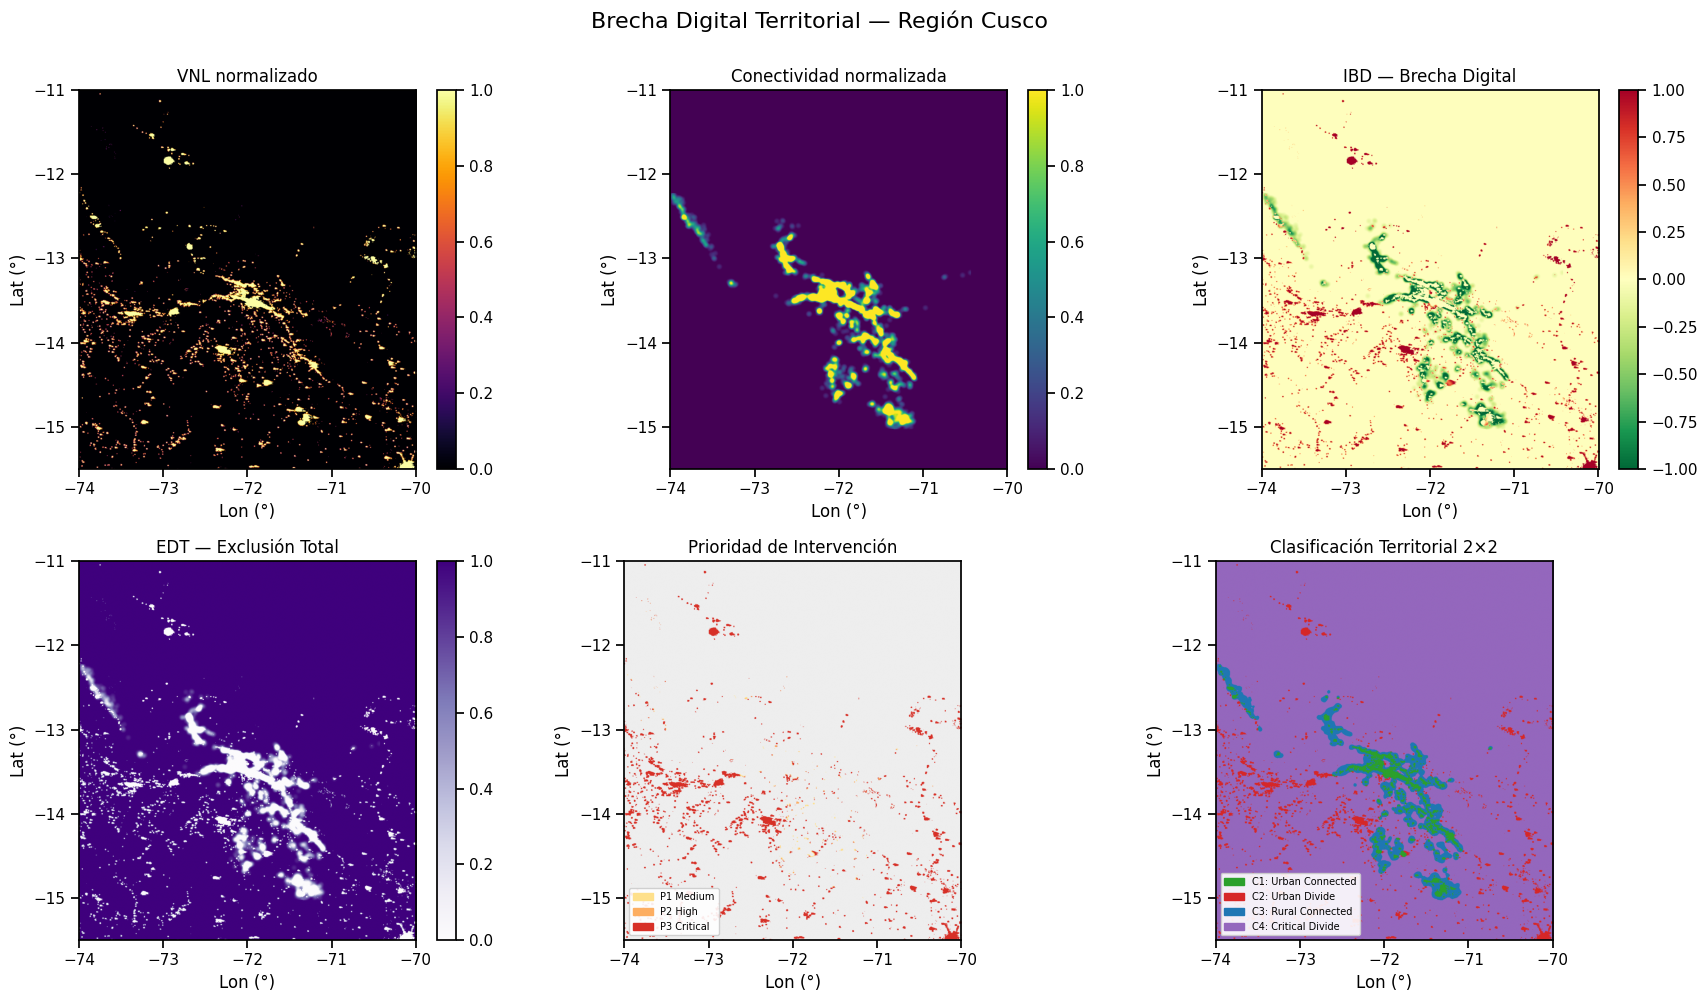


Dashboard guardado: C:\Users\manue\OneDrive\Documentos\GitHub\raster-digital-divide\output\dashboard_brecha_digital.png


In [11]:
def write_geotiff(path, arr, dtype='float32', nodata=None, compress='lzw'):
    prof = vnl_profile.copy()
    prof.update(dtype=dtype, count=1, nodata=nodata, compress=compress)
    with rasterio.open(path, 'w', **prof) as dst:
        dst.write(arr.astype(dtype), 1)

write_geotiff(OUT / 'vnl_norm.tif', vnl_norm, 'float32')
write_geotiff(OUT / 'conn_norm.tif', conn_norm, 'float32')
write_geotiff(OUT / 'ibd_brecha_digital.tif', ibd, 'float32')
# clasificacion_brecha.tif ya quedó guardado en el Step 8

print('GeoTIFFs exportados a output/:')
for f in ['vnl_norm.tif', 'conn_norm.tif', 'ibd_brecha_digital.tif', 'clasificacion_brecha.tif']:
    p = OUT / f
    sz_kb = p.stat().st_size / 1024
    print(f'  {f:34s}  {sz_kb:8.1f} KB')

# Dashboard composite: 2 filas x 3 columnas
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

ax = axs[0, 0]
im = ax.imshow(vnl_norm, cmap='inferno', extent=extent_geo, origin='upper', vmin=0, vmax=1)
ax.set_title('VNL normalizado')
ax.set_xlabel('Lon (°)'); ax.set_ylabel('Lat (°)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axs[0, 1]
im = ax.imshow(conn_norm, cmap='viridis', extent=extent_geo, origin='upper', vmin=0, vmax=1)
ax.set_title('Conectividad normalizada')
ax.set_xlabel('Lon (°)'); ax.set_ylabel('Lat (°)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axs[0, 2]
im = ax.imshow(ibd, cmap='RdYlGn_r', extent=extent_geo, origin='upper', vmin=-1, vmax=1)
ax.set_title('IBD — Brecha Digital')
ax.set_xlabel('Lon (°)'); ax.set_ylabel('Lat (°)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axs[1, 0]
im = ax.imshow(edt, cmap='Purples', extent=extent_geo, origin='upper', vmin=0, vmax=1)
ax.set_title('EDT — Exclusión Total')
ax.set_xlabel('Lon (°)'); ax.set_ylabel('Lat (°)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axs[1, 1]
ax.imshow(priority, cmap=prio_cmap, norm=prio_norm, extent=extent_geo, origin='upper')
ax.set_title('Prioridad de Intervención')
ax.set_xlabel('Lon (°)'); ax.set_ylabel('Lat (°)')
prio_short = ['', 'P1 Medium', 'P2 High', 'P3 Critical']
handles_p = [mpatches.Patch(color=prio_colors[i], label=prio_short[i]) for i in range(1, 4)]
ax.legend(handles=handles_p, loc='lower left', fontsize=7, framealpha=0.9)

ax = axs[1, 2]
ax.imshow(clasif, cmap=cl_cmap, norm=cl_bnorm, extent=extent_geo, origin='upper')
ax.set_title('Clasificación Territorial 2×2')
ax.set_xlabel('Lon (°)'); ax.set_ylabel('Lat (°)')
handles_c = [mpatches.Patch(color=class_colors[i], label=f'C{i}: {class_names[i]}') for i in range(1, 5)]
ax.legend(handles=handles_c, loc='lower left', fontsize=7, framealpha=0.9)

fig.suptitle('Brecha Digital Territorial — Región Cusco', fontsize=16, y=1.00)
plt.tight_layout()
dash_path = OUT / 'dashboard_brecha_digital.png'
plt.savefig(dash_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDashboard guardado: {dash_path}')